# 📈 Verificación Avanzada de Estacionalidad — Rentas Cedidas

**Componente de Tesis: Diagnóstico de Estructura Estocástica**

Este notebook valida la presencia de estacionalidad determinística y estocástica en la serie
de recaudo, aplicando descomposición STL (Seasonal-Trend-Loess) y tests formales.
Los resultados fundamentan la selección del orden estacional $s=12$ en los modelos SARIMA.

---

In [1]:
import sys
sys.path.insert(0, '.')
sys.path.insert(0, '../scripts')
%run 00_config.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf
from utils import cargar_datos, agregar_mensual, test_estacionariedad, formato_pesos

  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
✅ Config cargada — Datos: BaseRentasVF_2022_2025.xlsx | Periodo: 2022-01-01 a 2025-12-31
  🎨 Tema profesional activo — DPI 300, tipografía serif, paleta académica


✅ Config cargada — Datos: BaseRentasVF_2022_2025.xlsx | Periodo: 2022-01-01 a 2025-12-31
  🎨 Tema profesional activo — DPI 300, tipografía serif, paleta académica


## 1. Carga de la Serie Mensual

In [2]:
# Cargar serie preprocesada o generar desde Excel
try:
    df_mensual = pd.read_csv(DATA_PROCESSED / 'serie_mensual.csv', index_col=0, parse_dates=True)
    print(f'✅ Serie mensual cargada desde CSV: {len(df_mensual)} meses')
except FileNotFoundError:
    df = cargar_datos(DATA_FILE)
    df_mensual = agregar_mensual(df)
    df_mensual.to_csv(DATA_PROCESSED / 'serie_mensual.csv')

df_mensual.head()

✅ Serie mensual cargada desde CSV: 48 meses


,Recaudo_Neto
FechaRecaudo,
2022-01-01,3.042593e+11
2022-02-01,1.799829e+11
2022-03-01,2.765862e+11
2022-04-01,1.905671e+11
2022-05-01,1.810644e+11


## 2. Descomposición STL (Seasonal-Trend-Loess)

La descomposición STL es robusta frente a outliers y permite que el componente estacional
varíe en el tiempo, a diferencia de la descomposición clásica aditiva.

$$Y_t = T_t + S_t + R_t$$

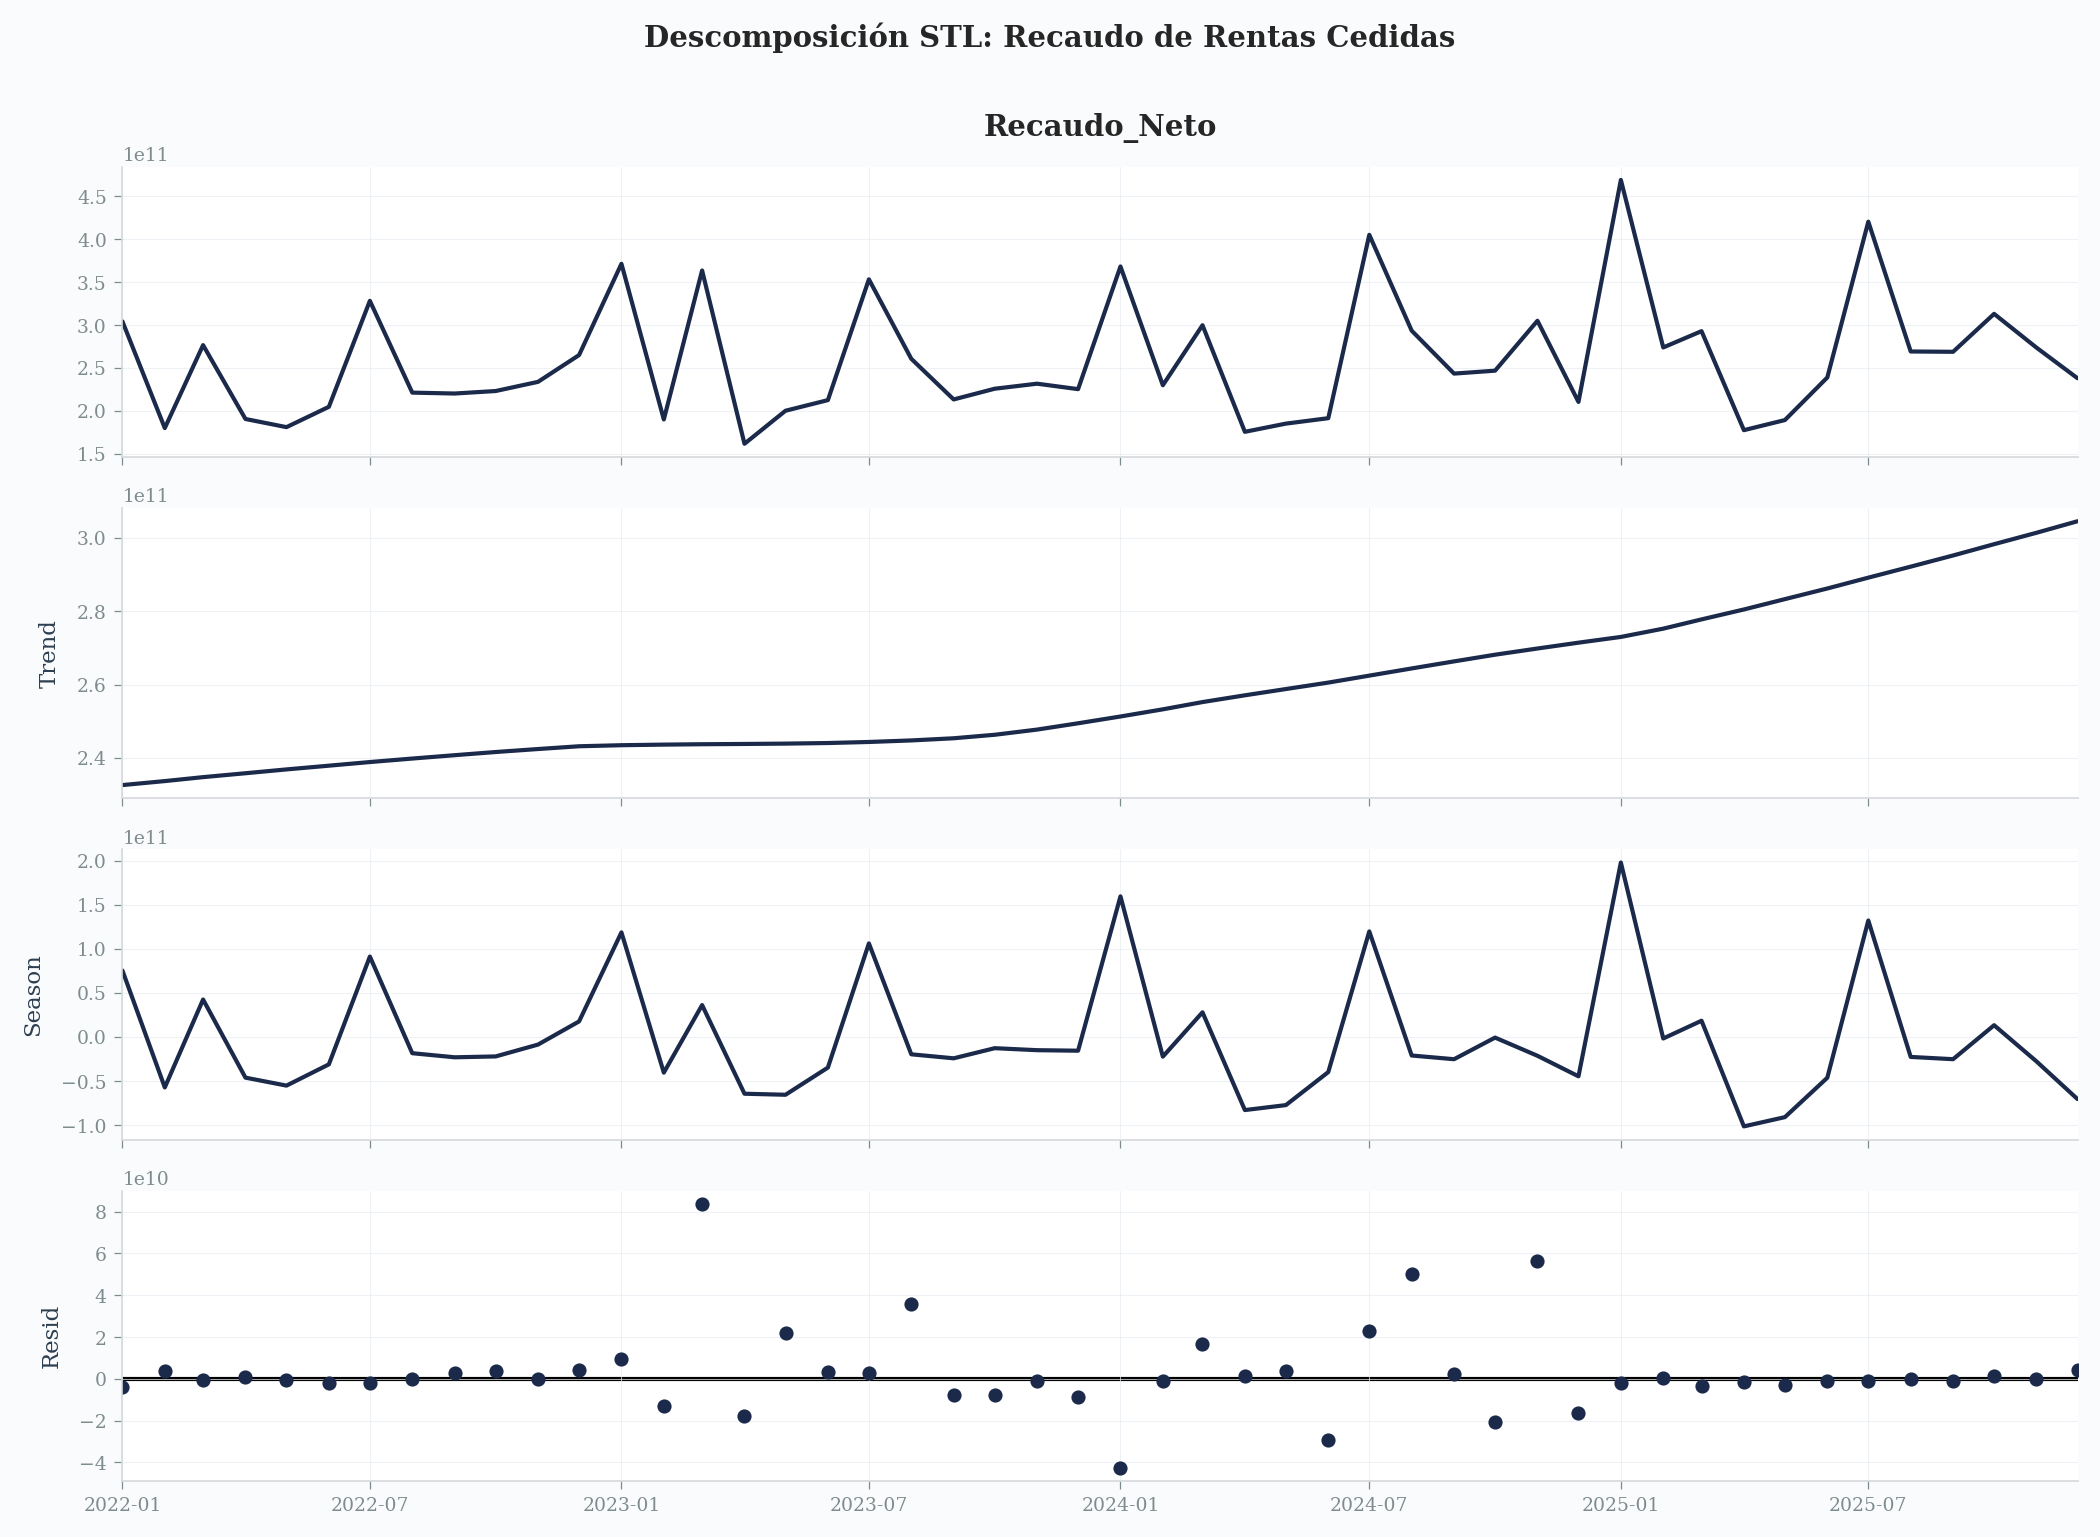


📊 Fuerza de la Estacionalidad (F_s): 0.9160
   Interpretación: Fuerte (umbral: 0.64)


In [3]:
# 2.1 Descomposición STL
stl = STL(df_mensual['Recaudo_Neto'], period=ESTACIONALIDAD, robust=True)
resultado_stl = stl.fit()

fig = resultado_stl.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Descomposición STL: Recaudo de Rentas Cedidas', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '02_descomposicion_stl.png', dpi=150, bbox_inches='tight')
plt.show()

# Fuerza de la estacionalidad
var_resid = np.var(resultado_stl.resid)
var_seasonal_plus_resid = np.var(resultado_stl.seasonal + resultado_stl.resid)
F_s = max(0, 1 - var_resid / var_seasonal_plus_resid)
print(f'\n📊 Fuerza de la Estacionalidad (F_s): {F_s:.4f}')
print(f'   Interpretación: {"Fuerte" if F_s > 0.64 else "Débil"} (umbral: 0.64)')

## 3. Identificación de Picos Estacionales

In [4]:
# 3.1 Recaudo promedio por mes con variación respecto a la media
df_estacional = df_mensual.copy()
df_estacional['Mes'] = df_estacional.index.month

promedio_mes = df_estacional.groupby('Mes')['Recaudo_Neto'].mean()
media_general = promedio_mes.mean()

meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

print('\n📊 RECAUDO PROMEDIO POR MES')
print(f'{"Mes":>5} {"Promedio":>18} {"vs Media":>10} {"Categoría":>12}')
print('-' * 50)
for mes in range(1, 13):
    if mes in promedio_mes.index:
        val = promedio_mes[mes]
        pct = (val - media_general) / media_general * 100
        cat = '🔴 PICO' if pct > 30 else ('🟡 Alto' if pct > 10 else ('🟢 Normal' if pct > -10 else '🔵 Bajo'))
        print(f'{meses_nombres[mes-1]:>5} {formato_pesos(val):>18} {pct:>+8.1f}% {cat:>12}')


📊 RECAUDO PROMEDIO POR MES
  Mes           Promedio   vs Media    Categoría
--------------------------------------------------
  Ene          $378.20MM    +46.2%       🔴 PICO
  Feb          $218.43MM    -15.6%       🔵 Bajo
  Mar          $308.20MM    +19.1%       🟡 Alto
  Abr          $176.36MM    -31.8%       🔵 Bajo
  May          $188.93MM    -27.0%       🔵 Bajo
  Jun          $211.92MM    -18.1%       🔵 Bajo
  Jul          $376.71MM    +45.6%       🔴 PICO
  Ago          $261.14MM     +0.9%     🟢 Normal
  Sep          $236.45MM     -8.6%     🟢 Normal
  Oct          $252.20MM     -2.5%     🟢 Normal
  Nov          $261.04MM     +0.9%     🟢 Normal
  Dic          $234.70MM     -9.3%     🟢 Normal


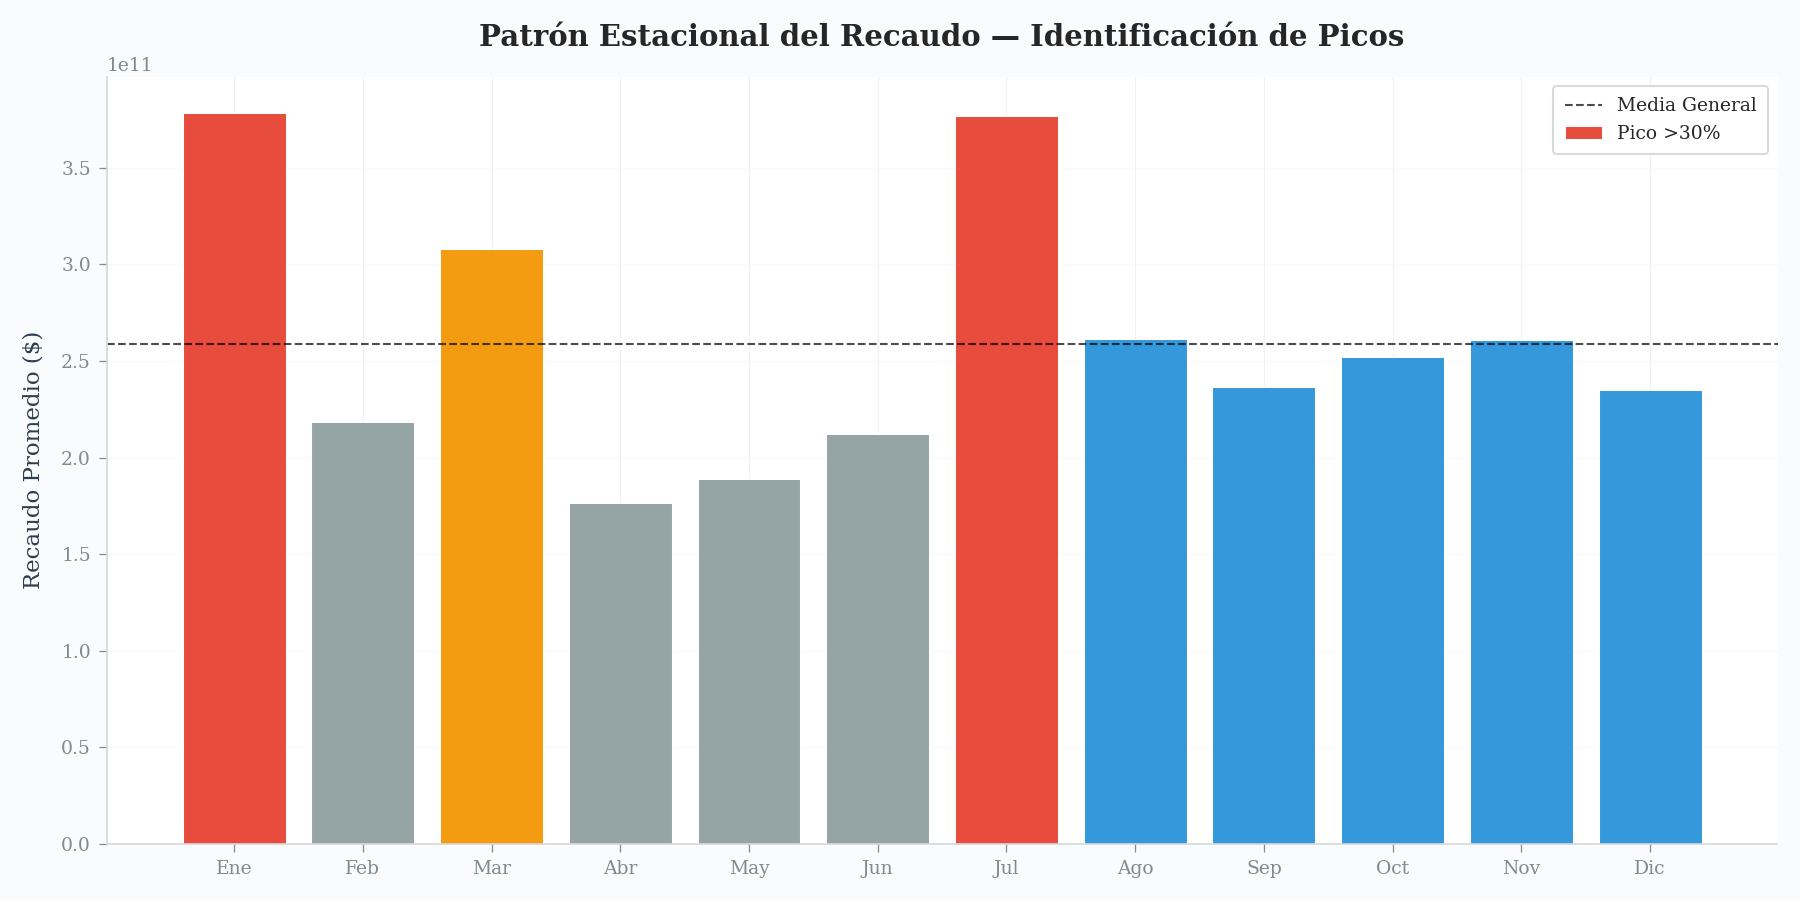

In [5]:
# 3.2 Barplot de estacionalidad con código de colores
fig, ax = plt.subplots(figsize=(12, 6))

colores_bar = []
for m in range(1, 13):
    if m in promedio_mes.index:
        pct = (promedio_mes[m] - media_general) / media_general * 100
        if pct > 30:
            colores_bar.append('#E74C3C')  # Pico
        elif pct > 10:
            colores_bar.append('#F39C12')  # Alto
        elif pct > -10:
            colores_bar.append('#3498DB')  # Normal
        else:
            colores_bar.append('#95A5A6')  # Bajo
    else:
        colores_bar.append('#95A5A6')

bars = ax.bar(range(1, 13), [promedio_mes.get(m, 0) for m in range(1, 13)], 
              color=colores_bar, edgecolor='white', linewidth=0.5)

ax.axhline(y=media_general, color='black', linestyle='--', linewidth=1, alpha=0.7, label='Media General')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_nombres)
ax.set_title('Patrón Estacional del Recaudo — Identificación de Picos', fontweight='bold', fontsize=14)
ax.set_ylabel('Recaudo Promedio ($)')
ax.legend(['Media General', 'Pico >30%', 'Alto >10%', 'Normal', 'Bajo'], loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '02_estacionalidad_picos.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Test de Differenciación Estacional


  PRUEBAS DE ESTACIONARIEDAD: Diferencia Estacional (D=12)

📊 Prueba ADF (H0: raíz unitaria)
   Estadístico: -7.0849
   p-valor:     0.0000
   Resultado:   ✅ Estacionaria

📊 Prueba KPSS (H0: estacionaria)
   Estadístico: 0.1318
   p-valor:     0.1000
   Resultado:   ✅ Estacionaria


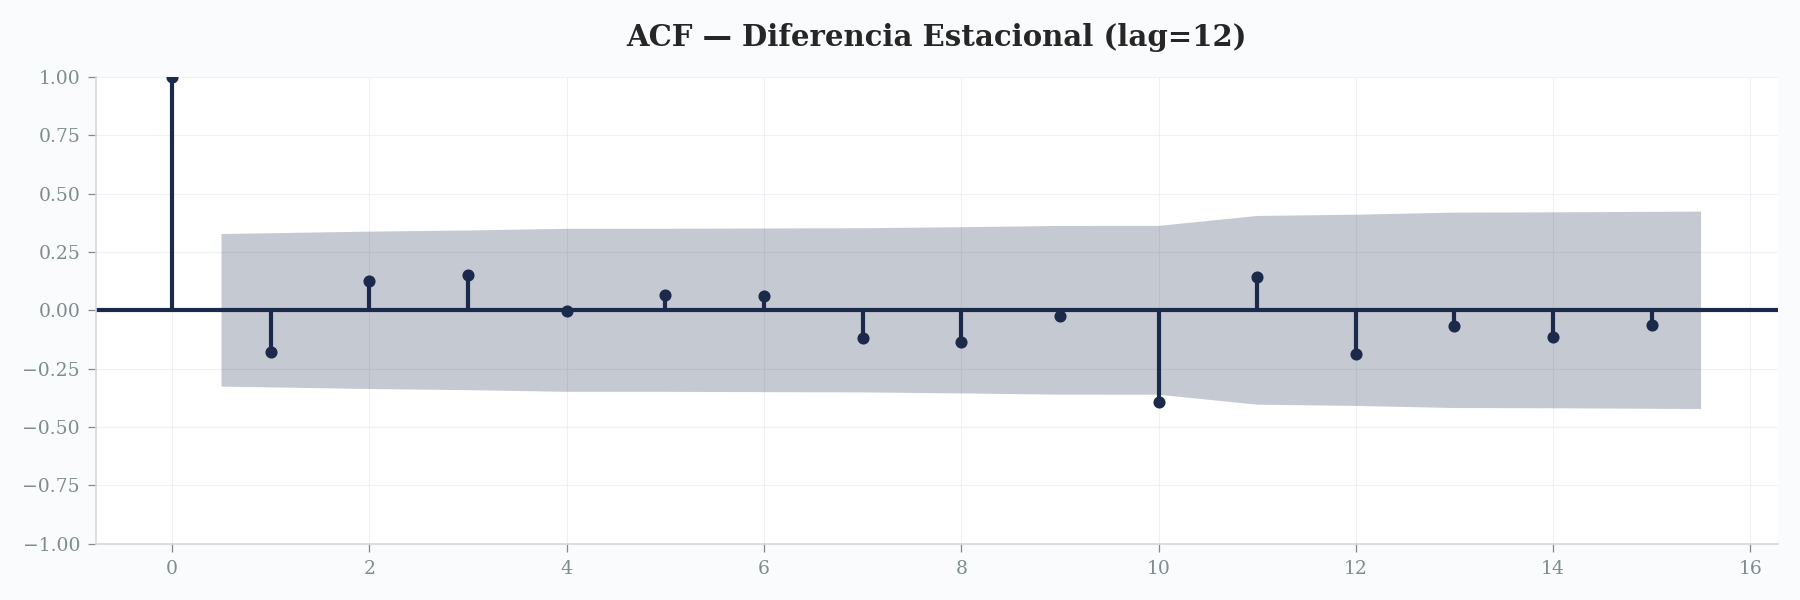


  ✅ ESTACIONALIDAD VERIFICADA — Proceder con 03_Correlacion_Macro.ipynb


In [6]:
# 4.1 ADF en diferencia estacional (lag 12)
diff_12 = df_mensual['Recaudo_Neto'].diff(12).dropna()
resultados = test_estacionariedad(diff_12, 'Diferencia Estacional (D=12)')

# 4.2 ACF de la diferencia estacional
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(diff_12, lags=15, ax=ax, title='ACF — Diferencia Estacional (lag=12)')
plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '02_acf_diff_estacional.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*60)
print('  ✅ ESTACIONALIDAD VERIFICADA — Proceder con 03_Correlacion_Macro.ipynb')
print('='*60)